In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pickle
import pandas as pd

Mounted at /content/drive


<ipython-input-6-d5be6116a9dd>:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date and Month'] = pd.to_datetime(data['Date and Month'])


Mean Squared Error: 2.2723849412546402e-20
Mean Absolute Error: 1.2243680399039696e-10


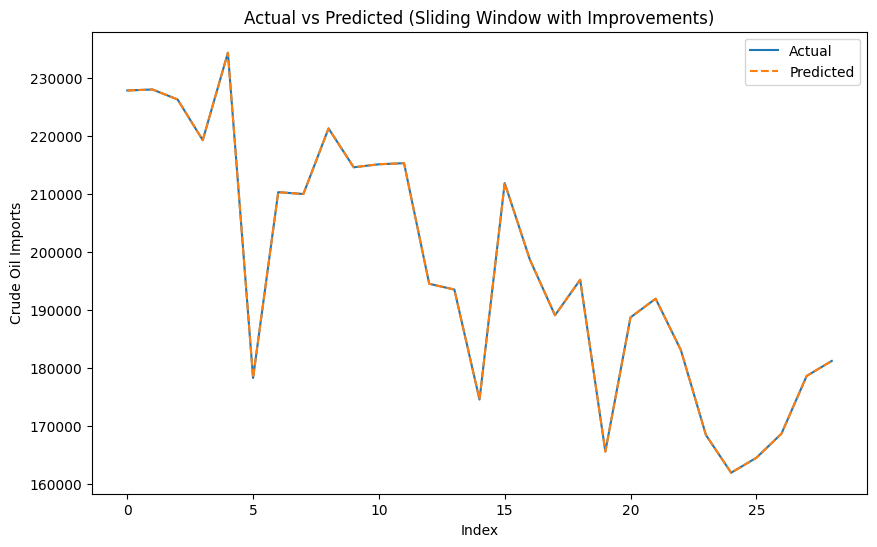

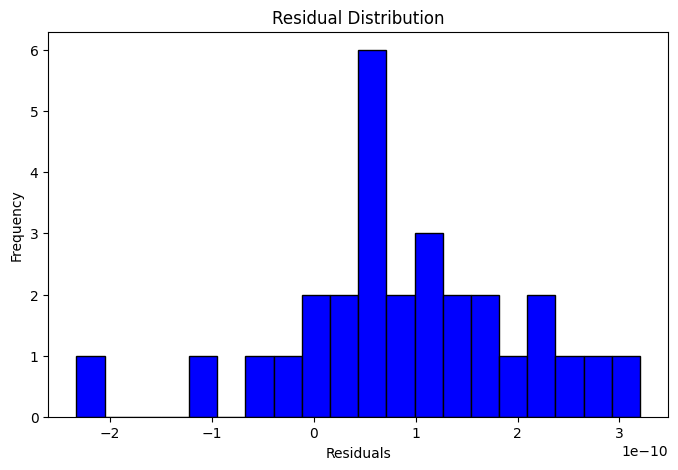

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/content/drive/My Drive/psd/tugas/dataset/Imports Oil.csv")

# Preprocessing
data['Date and Month'] = pd.to_datetime(data['Date and Month'])
data = data.sort_values(by='Date and Month')  # Pastikan data berurutan berdasarkan waktu

# Rolling mean and standard deviation
window_size = 3  # Jumlah nilai sebelumnya yang digunakan untuk prediksi
data['Rolling_Mean'] = data['Crude oil imports from the World to the US (a thousand barrels)'].rolling(window=window_size).mean()
data['Rolling_Std'] = data['Crude oil imports from the World to the US (a thousand barrels)'].rolling(window=window_size).std()

# Create sliding window features
X, y = [], []
values = data['Crude oil imports from the World to the US (a thousand barrels)'].values

for i in range(window_size, len(values)):
    # Tambahkan rolling mean dan std ke fitur
    feature_window = values[i-window_size:i]
    rolling_mean = data['Rolling_Mean'].iloc[i]
    rolling_std = data['Rolling_Std'].iloc[i]

    # Kombinasikan fitur sliding window dengan rolling statistics
    X.append(np.append(feature_window, [rolling_mean, rolling_std]))
    y.append(values[i])  # Target adalah nilai saat ini

X = np.array(X)
y = np.array(y)

# Drop NaN rows akibat rolling mean dan std
X = X[~np.isnan(X).any(axis=1)]
y = y[~np.isnan(y)]

# Split data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

# Visualisasi hasil prediksi
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label="Actual")
plt.plot(range(len(y_pred)), y_pred, label="Predicted", linestyle='--')
plt.xlabel('Index')
plt.ylabel('Crude Oil Imports')
plt.title('Actual vs Predicted (Sliding Window with Improvements)')
plt.legend()
plt.show()

# Distribusi residual
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, color='blue', edgecolor='black')
plt.title('Residual Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


Prediksi Crude Oil Imports untuk bulan depan: -3.31


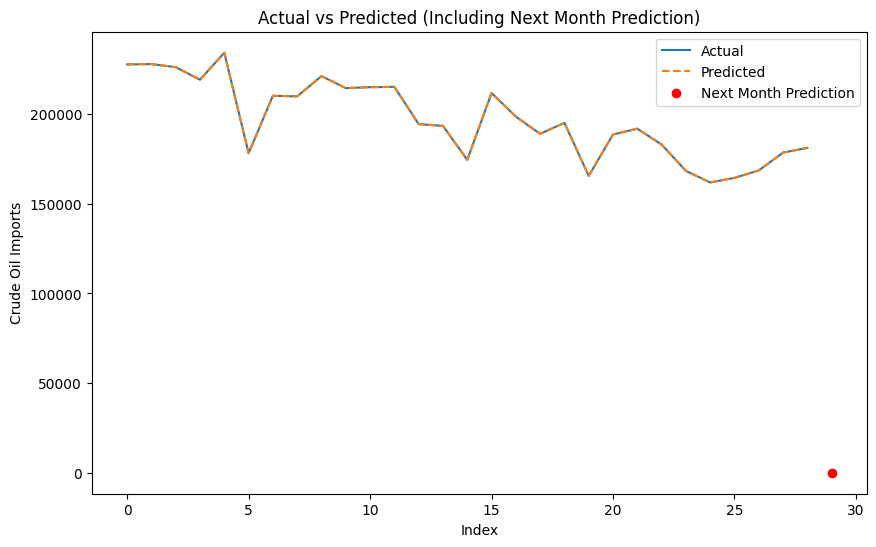

In [7]:
# Ambil 2 input terakhir dari data
latest_window = X_test[-1, :-2]  # Nilai sliding window terakhir tanpa rolling mean dan std
latest_mean = X_test[-1, -2]     # Rolling mean terakhir
latest_std = X_test[-1, -1]      # Rolling std terakhir

# Gabungkan ke dalam satu array input
next_input = np.append(latest_window, [latest_mean, latest_std])
next_input = next_input.reshape(1, -1)  # Ubah menjadi 2D array

# Transform input menggunakan scaler
next_input_scaled = scaler.transform(next_input)

# Prediksi bulan depan
next_prediction = model.predict(next_input_scaled)
print(f"Prediksi Crude Oil Imports untuk bulan depan: {next_prediction[0]:.2f}")

# Tambahkan ke grafik prediksi sebelumnya
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label="Actual")
plt.plot(range(len(y_pred)), y_pred, label="Predicted", linestyle='--')

# Plot prediksi bulan depan
plt.scatter(len(y_test), next_prediction, color='red', label="Next Month Prediction")
plt.xlabel('Index')
plt.ylabel('Crude Oil Imports')
plt.title('Actual vs Predicted (Including Next Month Prediction)')
plt.legend()
plt.show()
